In [1]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
import shap

In [4]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()
model = joblib.load('../models/lr_best_model.pkl')
# background sample — 100 random rows from training data
background = X_train.sample(100, random_state=42)

# explainer using predict_proba of the full pipeline
explainer = shap.Explainer(model.predict_proba, background)

# calculate shap values for test set
shap_values = explainer(X_test)

shap.initjs()

PermutationExplainer explainer: 185it [00:14, 10.98it/s]                         


C:\Users\pulki\AppData\Local\Temp\ipykernel_33328\3452908339.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 1], X_test, plot_type='bar')


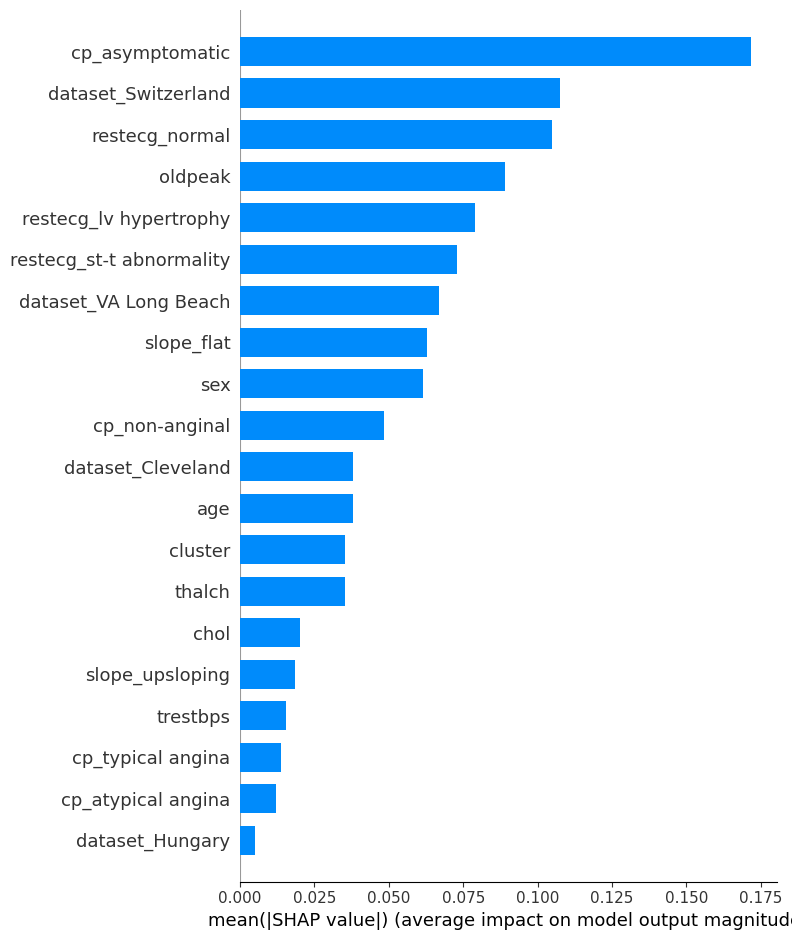

In [5]:
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type='bar')

C:\Users\pulki\AppData\Local\Temp\ipykernel_33328\2344957999.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 1], X_test)


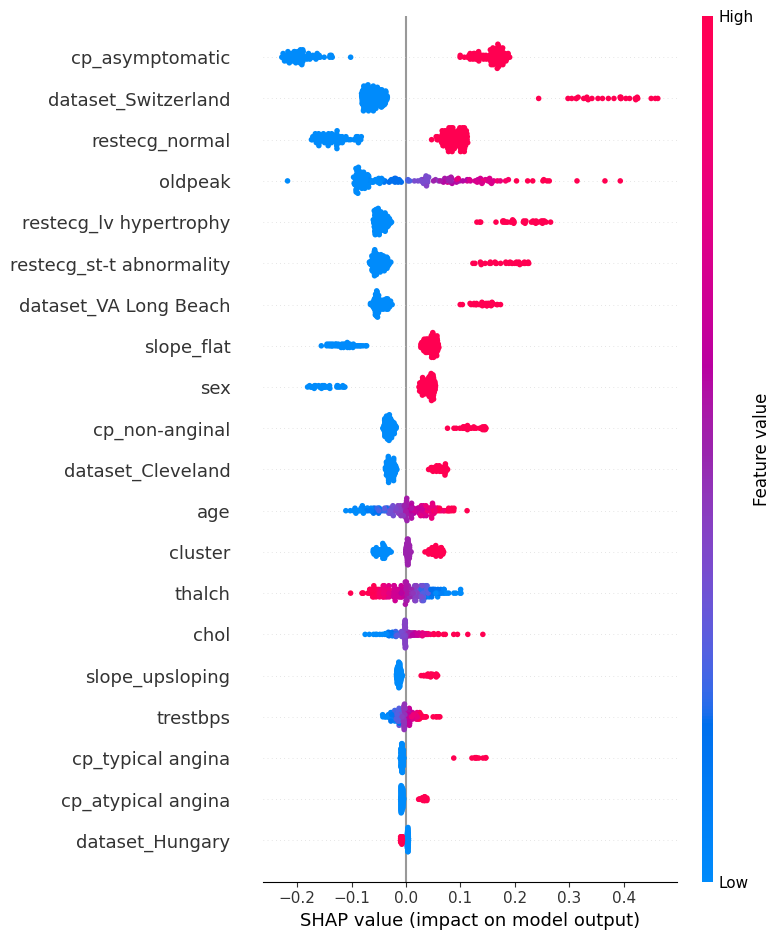

In [6]:
shap.summary_plot(shap_values[:, :, 1], X_test)

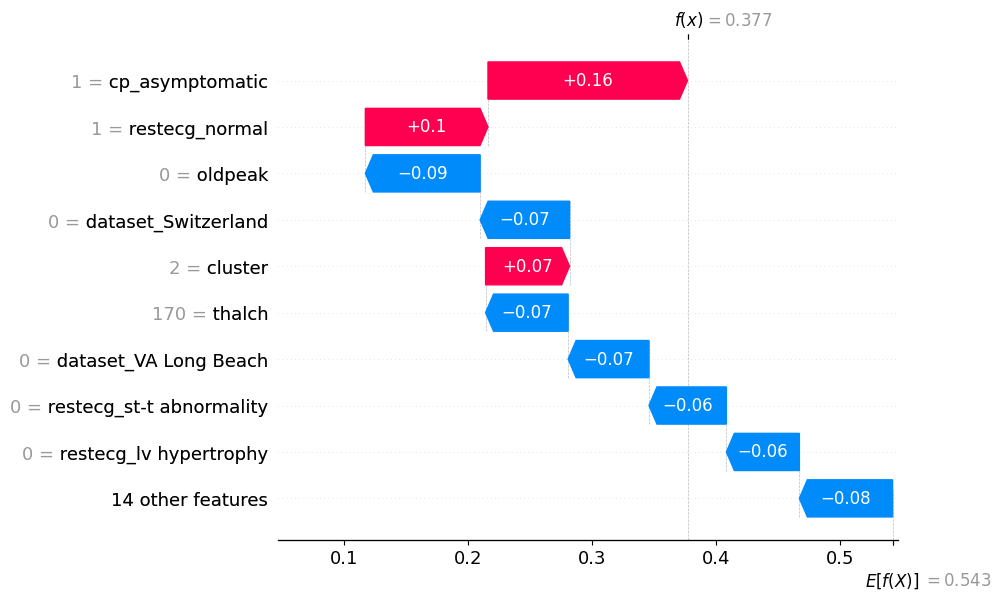

In [7]:
shap.plots.waterfall(shap_values[0, :, 1])

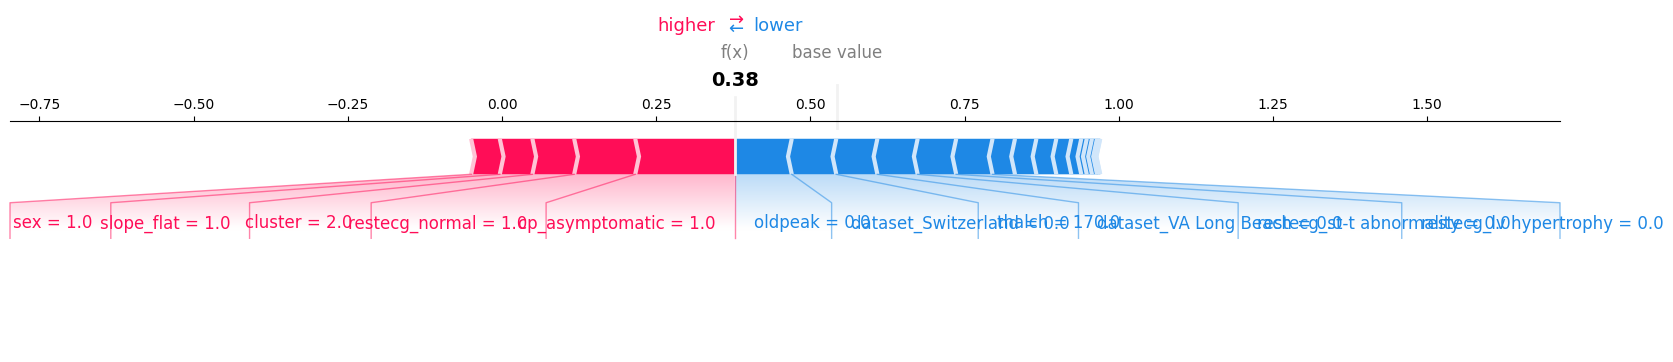

In [9]:
shap.force_plot(
    shap_values[0, :, 1].base_values,
    shap_values[0, :, 1].values,
    X_test.iloc[0],
    matplotlib=True
)
plt.show()